# Day 29 - Customer Churn Logistic Regression

## 학습 주제

고객의 과거 행동 데이터를 이용하여 향후 30일 이탈 여부를 예측하는 분류 문제를 학습한다.

이번 분석에서는 다음 내용을 확인한다.

- Classification
- Logistic Regression
- Baseline
- Predicted Probability
- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1 Score
- Classification Threshold

## 분석 질문

1. 과거 고객 행동을 이용해 향후 30일 이탈 여부를 예측할 수 있는가?
2. Logistic Regression은 단순 Baseline보다 나은가?
3. 모델은 실제 이탈 고객을 얼마나 찾아내는가?
4. 이탈이라고 예측한 고객 중 실제 이탈 고객은 얼마나 되는가?
5. Threshold를 변경하면 Precision과 Recall은 어떻게 달라지는가?

## 데이터와 Target

이번 데이터는 머신러닝 학습 목적으로 만든 800명의 가상 고객 데이터다.

Feature는 모두 예측 시점 이전의 고객 행동을 의미한다.

Target:

- next_30d_churn = 0: 향후 30일 이탈하지 않음
- next_30d_churn = 1: 향후 30일 이탈

customer_id는 고객을 구분하기 위한 식별자이므로 Feature로 사용하지 않는다.

이 데이터는 가상 데이터이므로 실제 고객 행동이나 실제 기업의 이탈률을 의미하지 않는다.

In [1]:
# 라이브러리
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

In [2]:
# 루트 저장
project_root = Path.cwd().parent

input_path = (
    project_root
    / "data"
    / "raw"
    / "day29_customer_churn_classification.csv"
)

output_dir = (
    project_root
    / "outputs"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

print(
    input_path
)

print(
    output_dir
)

d:\Study\Projects\00_foundation_review\data\raw\day29_customer_churn_classification.csv
d:\Study\Projects\00_foundation_review\outputs


In [3]:
# 데이터 불러오기
df = pd.read_csv(
    input_path
)

print(
    df.head()
)

   customer_id  login_days_30d  order_count_90d  support_tickets_90d  \
0            1               2                3                    5   
1            2              23                4                    3   
2            3              20                3                    3   
3            4              13                1                    5   
4            5              13                1                    0   

   membership_months  days_since_last_login  billing_issue_count_90d  \
0                 36                     11                        1   
1                 20                     38                        0   
2                 58                     28                        1   
3                 44                     15                        0   
4                 45                     28                        1   

   next_30d_churn  
0               1  
1               1  
2               0  
3               0  
4               1  


In [4]:
# 구조 확인
print(
    df.shape
)

print(
    df.dtypes
)

print(
    df.isna().sum()
)

(800, 8)
customer_id                int64
login_days_30d             int64
order_count_90d            int64
support_tickets_90d        int64
membership_months          int64
days_since_last_login      int64
billing_issue_count_90d    int64
next_30d_churn             int64
dtype: object
customer_id                0
login_days_30d             0
order_count_90d            0
support_tickets_90d        0
membership_months          0
days_since_last_login      0
billing_issue_count_90d    0
next_30d_churn             0
dtype: int64


In [5]:
# 이탈률 확인
churn_count = (
    df["next_30d_churn"]
    .value_counts()
    .sort_index()
)

churn_rate = (
    df["next_30d_churn"]
    .mean()
)

print(
    churn_count
)

print(
    f"이탈률: {churn_rate:.1%}"
)

next_30d_churn
0    478
1    322
Name: count, dtype: int64
이탈률: 40.2%


## Feature와 Target 정의

이번 문제의 Target은 향후 30일 이탈 여부다.

Feature에는 예측 시점 이전에 알 수 있는 고객 행동만 사용한다.

customer_id는 단순 식별자이므로 모델 학습에 사용하지 않는다.

In [ ]:
features = [
    "login_days_30d",
    "order_count_90d",
    "support_tickets_90d",
    "membership_months",
    "days_since_last_login",
    "billing_issue_count_90d"
]

X = df[
    features
]

y = df[
    "next_30d_churn"
]

print(
    X.head()
)

print(
    y.head()
)

   login_days_30d  order_count_90d  support_tickets_90d  membership_months  \
0               2                3                    5                 36   
1              23                4                    3                 20   
2              20                3                    3                 58   
3              13                1                    5                 44   
4              13                1                    0                 45   

   days_since_last_login  billing_issue_count_90d  
0                     11                        1  
1                     38                        0  
2                     28                        1  
3                     15                        0  
4                     28                        1  
0    1
1    1
2    0
3    0
4    1
Name: next_30d_churn, dtype: int64


## Train / Test 분할

전체 데이터를 Train과 Test로 분리한다.

분류 문제에서는 전체 Target의 클래스 비율이 Train과 Test에서 크게 달라지지 않도록 stratify=y를 사용한다.

- Train: 모델 학습
- Test: 학습에 사용하지 않은 데이터에서 성능 확인

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.25,
    random_state = 42,
    stratify = y
)

print(
    X_train.shape
)

print(
    X_test.shape
)

print(
    y_train.shape
)

print(
    y_test.shape
)

(600, 6)
(200, 6)
(600,)
(200,)


## Classification Baseline

모델을 평가하기 전에 가장 단순한 기준선을 만든다.

이번 Baseline은 Train 데이터에서 가장 많은 클래스를 모든 Test 고객에게 예측하는 방식이다.

모델은 최소한 이 단순한 기준보다 나은 결과를 보여야 한다.

In [16]:
majority_class = (
    y_train
    .mode()[0]
)

baseline_prediction = (
    [majority_class] 
    * len(y_test)
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_prediction
)

print(
    f"Majority Class: {majority_class}"
)

print(
    f"Baseline Accuracy: {baseline_accuracy:.3f}"
)


Majority Class: 0
Baseline Accuracy: 0.600


## Logistic Regression

Logistic Regression은 Feature를 이용하여 클래스 1의 확률을 계산하는 분류 모델이다.

이번 문제에서는:

- Class 0 = 유지
- Class 1 = 이탈

이다.

모델은 먼저 이탈확률을 계산하고 이를 이용하여 최종 클래스를 예측한다.

In [17]:
model = LogisticRegression()

md = model.fit(
    X_train,
    y_train
)

## Predicted Probability

predict()는 최종 클래스 0 또는 1을 반환한다.

predict_proba()는 각 클래스가 될 확률을 반환한다.

분류 모델에서는 최종 클래스뿐 아니라 예측확률도 중요한 정보다.

In [26]:
probability = model.predict_proba(
    X_test
)

print(
    probability[:4]
)

[[0.3997963  0.6002037 ]
 [0.76517887 0.23482113]
 [0.59247366 0.40752634]
 [0.67223761 0.32776239]]


In [27]:
no_churn_probability = (
    probability[
        :,
        0
    ]
)

churn_probability = (
    probability[
        :,
        1
    ]
)

print(
    churn_probability[:10]
)

[0.6002037  0.23482113 0.40752634 0.32776239 0.17472469 0.60400753
 0.75029537 0.1270885  0.78135808 0.68890065]


In [29]:
# 죄종 클래스 예측
prediction = model.predict(
    X_test
)

print(
    prediction[:20]
)
print(
    prediction.mean()
)

[1 0 0 0 0 1 1 0 1 1 0 1 0 1 0 1 0 1 0 1]
0.375


In [30]:
# 평가지표
accuracy = accuracy_score(
    y_test,
    prediction
)

precision = precision_score(
    y_test,
    prediction
)

recall = recall_score(
    y_test,
    prediction
)

f1 = f1_score(
    y_test,
    prediction
)

print(
    f"Baseline Accuracy: {baseline_accuracy:.3f}"
)

print(
    f"Model Accuracy: {accuracy:.3f}"
)

print(
    f"Precision: {precision:.3f}"
)

print(
    f"Recall: {recall:.3f}"
)

print(
    f"F1: {f1:.3f}"
)

Baseline Accuracy: 0.600
Model Accuracy: 0.725
Precision: 0.667
Recall: 0.625
F1: 0.645


In [ ]:
# Confusion Maxtrix
confusion = confusion_matrix(
    y_test,
    prediction
)

confusion_df = pd.DataFrame(
    confusion,
    index = [
        "actual_0",
        "actual_1"
    ],
    columns = [
        "predicted_0",
        "predicted_1"
    ]
)

print(
    confusion_df
)

## TN = 95
## FP = 25
## FN = 30
## TP = 50

          predicted_0  predicted_1
actual_0           95           25
actual_1           30           50


## Confusion Matrix 해석

- TN: 실제 유지 고객을 유지 고객으로 정확히 예측
- FP: 실제 유지 고객을 이탈 고객으로 잘못 예측
- FN: 실제 이탈 고객을 유지 고객으로 잘못 예측
- TP: 실제 이탈 고객을 이탈 고객으로 정확히 예측

분류 모델에서는 전체 정답률뿐 아니라 어떤 종류의 오류가 발생했는지를 함께 확인해야 한다.

특히 이탈 예측에서는 FP와 FN의 업무 비용이 서로 다를 수 있다.

In [32]:
# 결과 표
metrics_df = pd.DataFrame(
    {
        "metric": [
            "baseline_accuracy",
            "accuracy",
            "precision",
            "recall",
            "f1",
        ],
        "score": [
            baseline_accuracy,
            accuracy,
            precision,
            recall,
            f1,
        ],
    }
)

print(
    metrics_df
)

              metric     score
0  baseline_accuracy  0.600000
1           accuracy  0.725000
2          precision  0.666667
3             recall  0.625000
4                 f1  0.645161


In [33]:
# 고객별 예측 결과
prediction_df = pd.DataFrame(
    {
        "customer_id": df.loc[
            X_test.index,
            "customer_id"
        ],
        "actual_churn": y_test,
    }
)

prediction_df[
    "predicted_churn"
] = prediction

prediction_df[
    "predicted_churn_probability"
] = churn_probability

print(
    prediction_df.head(
        10
    )
)

     customer_id  actual_churn  predicted_churn  predicted_churn_probability
677          678             0                1                     0.600204
403          404             0                0                     0.234821
206          207             1                0                     0.407526
795          796             0                0                     0.327762
788          789             0                0                     0.174725
461          462             0                1                     0.604008
488          489             0                1                     0.750295
595          596             0                0                     0.127088
681          682             0                1                     0.781358
22            23             1                1                     0.688901


In [34]:
# csv 저장
metrics_path = (
    output_dir
    / "customer_churn_logistic_metrics.csv"
)

confusion_path = (
    output_dir
    / "customer_churn_logistic_confusion_matrix.csv"
)

prediction_path = (
    output_dir
    / "customer_churn_logistic_predictions.csv"
)

metrics_df.to_csv(
    metrics_path,
    index=False
)

confusion_df.to_csv(
    confusion_path
)

prediction_df.to_csv(
    prediction_path,
    index=False
)

print(
    metrics_path
)

print(
    confusion_path
)

print(
    prediction_path
)

d:\Study\Projects\00_foundation_review\outputs\customer_churn_logistic_metrics.csv
d:\Study\Projects\00_foundation_review\outputs\customer_churn_logistic_confusion_matrix.csv
d:\Study\Projects\00_foundation_review\outputs\customer_churn_logistic_predictions.csv


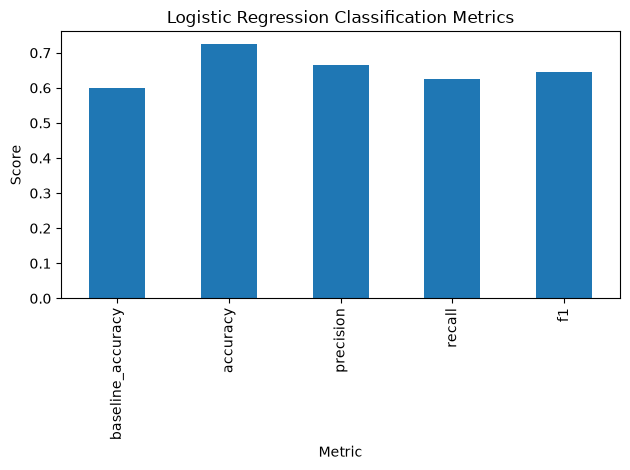

In [35]:
# 시각화
figure_path = (
    output_dir
    / "customer_churn_logistic_metric_comparison.png"
)

metrics_df.plot.bar(
    x="metric",
    y="score",
    legend=False
)

plt.title(
    "Logistic Regression Classification Metrics"
)

plt.xlabel(
    "Metric"
)

plt.ylabel(
    "Score"
)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Threshold Experiment

Logistic Regression은 먼저 클래스 1의 확률을 계산한다.

기본 분류 기준은 약 0.5이지만 업무 목적에 따라 기준을 변경할 수 있다.

이번에는 Threshold를 0.4로 낮추고 Precision과 Recall의 변화를 확인한다.

In [36]:
threshold = 0.4

threshold_prediction = (
    churn_probability
    >= threshold
).astype(
    int
)

threshold_accuracy = accuracy_score(
    y_test,
    threshold_prediction
)

threshold_precision = precision_score(
    y_test,
    threshold_prediction
)

threshold_recall = recall_score(
    y_test,
    threshold_prediction
)

threshold_f1 = f1_score(
    y_test,
    threshold_prediction
)

print(
    f"Threshold: {threshold}"
)

print(
    f"Accuracy: {threshold_accuracy:.3f}"
)

print(
    f"Precision: {threshold_precision:.3f}"
)

print(
    f"Recall: {threshold_recall:.3f}"
)

print(
    f"F1: {threshold_f1:.3f}"
)

Threshold: 0.4
Accuracy: 0.720
Precision: 0.620
Recall: 0.775
F1: 0.689


## 최종 해석

### 모델 성능

- Baseline Accuracy: 0.600
- Logistic Regression Accuracy: 0.725
- Precision: 0.667
- Recall: 0.625
- F1 Score: 0.645

### Confusion Matrix

- TN: 95
- FP: 25
- FN: 30
- TP: 50

### 결과 해석

Logistic Regression이 단순 다수 클래스 Baseline보다 높은 Accuracy를 보이는지 확인하였다.

Precision은 이탈이라고 예측한 고객 중 실제 이탈 고객의 비율을 의미하고, Recall은 실제 이탈 고객 중 모델이 찾아낸 고객의 비율을 의미한다.

따라서 어떤 평가 지표를 중요하게 볼지는 잘못 연락하는 비용과 실제 이탈 고객을 놓치는 비용 중 어느 것이 더 큰지에 따라 달라질 수 있다.

Threshold를 낮추면 일반적으로 더 많은 고객을 이탈 후보로 분류하므로 Recall은 증가하고 Precision은 감소할 수 있다.

### 한계

이번 데이터는 머신러닝 학습을 위해 생성한 가상 데이터이므로 실제 기업의 고객 이탈 행동을 의미하지 않는다.

또한 Feature와 이탈 사이의 예측 관계가 관측되더라도 해당 Feature가 고객 이탈의 인과적 원인이라고 해석해서는 안 된다.